# Nobel Prize Dataset Analysis

![Nobel Prize](../images/Nobel_Prize.png)

This project explores demographic and historical patterns among Nobel Prize laureates from 1901 to 2023.

The analysis focuses on gender representation, countries of birth, the share of U.S.-born laureates, and changes in female representation across decades and prize categories.

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


In [2]:
sns.set_theme(
    style='whitegrid',
    palette='Set2',
    font_scale=1.1,
    rc={"figure.figsize": (10, 5)}
)

In [3]:
df = pd.read_csv('../data/nobel.csv')
print(f'Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns')
display(df.head())

Dataset shape: 1000 rows and 18 columns


,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,birth_country,sex,organization_name,organization_city,organization_country,death_date,death_city,death_country
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,160,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Male,Berlin University,Berlin,Germany,1911-03-01,Berlin,Germany
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,569,Individual,Sully Prudhomme,1839-03-16,Paris,France,Male,NaN,NaN,NaN,1907-09-07,Châtenay,France
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,293,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Male,Marburg University,Marburg,Germany,1917-03-31,Marburg,Germany
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,462,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Male,NaN,NaN,NaN,1910-10-30,Heiden,Switzerland
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,463,Individual,Frédéric Passy,1822-05-20,Paris,France,Male,NaN,NaN,NaN,1912-06-12,Paris,France


## Data quality check

In [4]:
display(df.isna().sum().sort_values(ascending=False).to_frame(name='Missing Values'))
print(f"Duplicate rows: {df.duplicated().sum()}")

,Missing Values
death_city,421
death_country,415
death_date,404
organization_country,265
organization_city,265
organization_name,264
motivation,88
birth_city,36
birth_date,32
birth_country,31


Duplicate rows: 0


## 1. Gender distribution

<Axes: title={'center': 'Distribution of Nobel Prize Laureates by Gender'}, xlabel='Gender', ylabel='Number of laureates'>

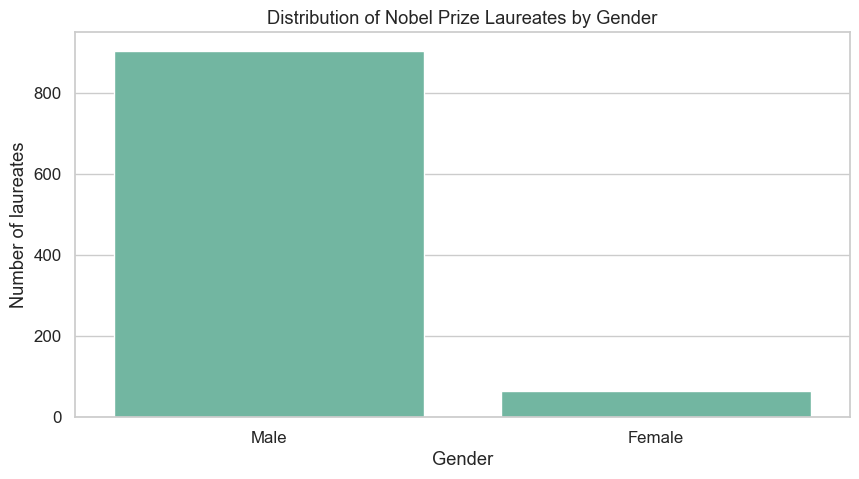

In [5]:
top_gender = 'Male'
plt.title('Distribution of Nobel Prize Laureates by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of laureates')
sns.countplot(df, x='sex')

## Countires of birth

In [6]:
top_country = 'United States of America'

countries = df['birth_country'].value_counts().head(10)
countries

birth_country
United States of America    291
United Kingdom               91
Germany                      67
France                       58
Sweden                       30
Japan                        28
Canada                       21
Switzerland                  19
Netherlands                  19
Italy                        18
Name: count, dtype: int64

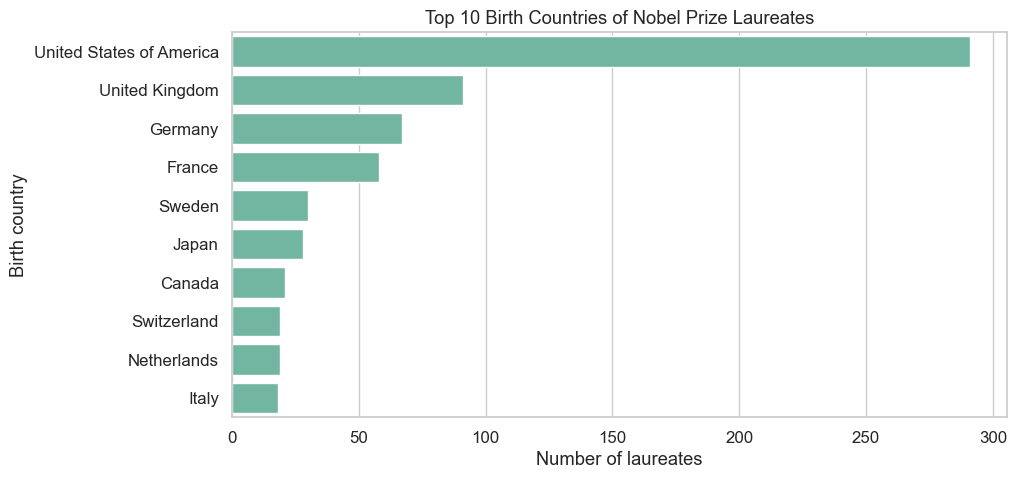

In [7]:
sns.barplot(x=countries.values, y=countries.index)
plt.title('Top 10 Birth Countries of Nobel Prize Laureates')
plt.xlabel('Number of laureates')
plt.ylabel('Birth country');

## 3. U.S.-born laureates over time

In [8]:
df['US_winners'] = df['birth_country'] == 'United States of America'
decades = (np.floor(df['year'] / 10) *10).astype(int)
df['decade'] = decades
ratio = df.groupby('decade', as_index=False)['US_winners'].mean()
max_ratio = ratio['US_winners'].max()
max_decade_usa = ratio[ratio['US_winners'] == max_ratio]['decade'].values[0]

print(f'The highest share of U.S.-born Nobel Prize laureates occurred in the {max_decade_usa}s.')


The highest share of U.S.-born Nobel Prize laureates occurred in the 2000s.


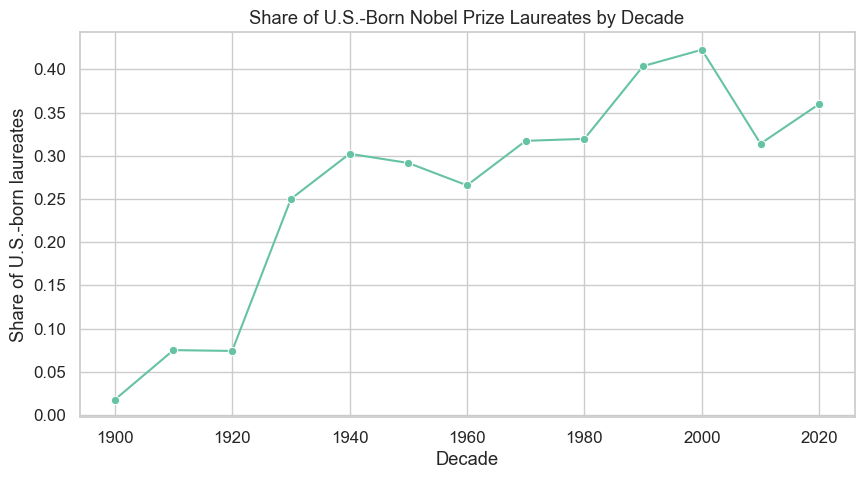

In [9]:
plt.title('Share of U.S.-Born Nobel Prize Laureates by Decade')
plt.xlabel('Decade')
plt.ylabel('Share of U.S.-born laureates')
sns.lineplot(data=ratio, x='decade', y='US_winners', marker='o');


## 4. Female representation by decade and category

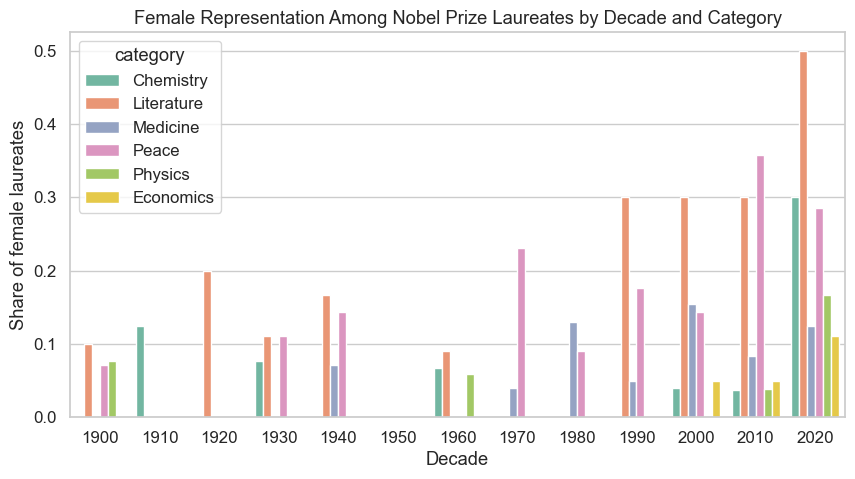

In [10]:
df['female_winner'] = df['sex'] == 'Female'
female_won = df.groupby(['decade', 'category'], as_index=False)['female_winner'].mean()

plt.title('Female Representation Among Nobel Prize Laureates by Decade and Category')
plt.xlabel('Decade')
plt.ylabel('Share of female laureates')
sns.barplot(data=female_won, x='decade', y='female_winner', hue='category');

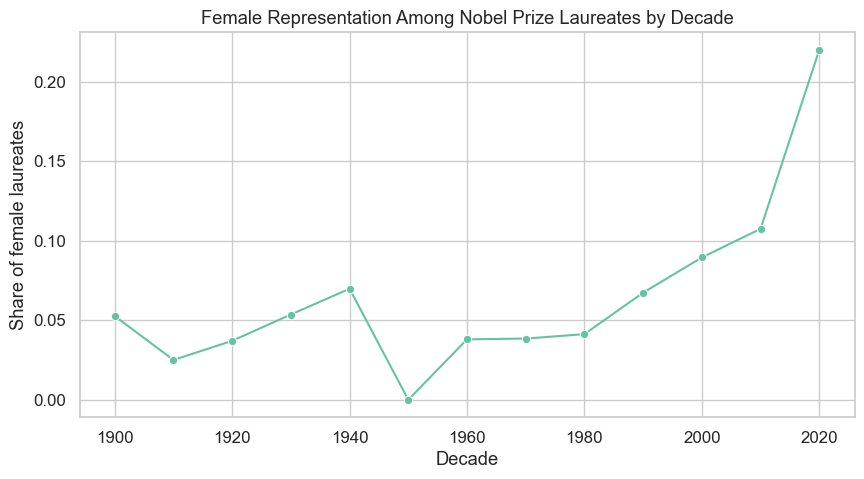

In [12]:
female_won_decade = df.groupby('decade', as_index=False)['female_winner'].mean()
plt.title('Female Representation Among Nobel Prize Laureates by Decade')
plt.xlabel('Decade')
plt.ylabel('Share of female laureates')
sns.lineplot(data=female_won_decade, x='decade', y='female_winner', marker='o');

In [17]:
highest_mean = female_won['female_winner'].max()
new_df = female_won[female_won['female_winner'] == highest_mean][['decade', 'category']]
max_female_dict = {
    new_df['decade'].values[0]: new_df['category'].values[0]
}
(key, value), = max_female_dict.items()
print(f'The highest share of female Nobel Prize laureates occurred in the {key}s in the category of {value}.')

The highest share of female Nobel Prize laureates occurred in the 2020s in the category of Literature.


## 5. First female Nobel Prize laureate

In [13]:
female_winners = df[df['sex'] == 'Female']
first_woman = female_winners[female_winners['year'] == female_winners['year'].min()]
first_woman_name = str(first_woman.iloc[0]['full_name'])
first_woman_category = str(first_woman.iloc[0]['category'])
print(f'First female laureate {first_woman_name} in {first_woman_category}')

First female laureate Marie Curie, née Sklodowska in Physics


## 6. Repeated laureates

In [18]:
repeated_names = df['full_name'].value_counts()
repeated_names = repeated_names[repeated_names >= 2]
display(repeated_names.to_frame(name='Number of Prizes').sort_values(by='Number of Prizes', ascending=False))

,Number of Prizes
full_name,
Comité international de la Croix Rouge (International Committee of the Red Cross),3
Linus Carl Pauling,2
John Bardeen,2
Frederick Sanger,2
"Marie Curie, née Sklodowska",2
Office of the United Nations High Commissioner for Refugees (UNHCR),2


## Key findings

- The dataset contains **1,000 Nobel Prize records** awarded between **1901 and 2023**.
- Men account for **905 laureates**, while women account for **65**; the gender is not recorded for **30** entries.
- The **United States of America** is the most common birth country, with **291 laureates** — more than three times as many as the United Kingdom (**91**).
- The share of U.S.-born laureates was highest in the **2000s**, when they represented approximately **42.3%** of all laureates in the dataset.
- Female representation increased in recent decades: from approximately **4.1% in the 1980s** to **22% in the 2020s**.
- The highest female representation for a decade–category combination occurred in **Literature in the 2020s**, where women represented **50%** of laureates.
- The first female laureate in the dataset was **Marie Curie**, who received the Nobel Prize in **Physics in 1903**.